# Oropouche en Brasil: 9× más casos en un año

**9.5 veces más casos. 16 estados nuevos. Y un mosquito que no vuela tan rápido.**

En 2023, Brasil reportó 831 casos de fiebre Oropouche, casi todos en la Amazonía. En 2024, fueron 7.931 — repartidos en 27 estados, llegando hasta la costa atlántica. ¿Cómo viaja un virus tan rápido cuando su vector (un jején diminuto) vuela apenas unos kilómetros al día?

📄 **Paper**: [Dynamics and ecology of a multistage expansion of Oropouche virus in Brazil](https://doi.org/10.1038/s41559-026-03042-0)
*Nature Ecology & Evolution · Abril 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-22-oropouche-expansion-brasil/notebook.ipynb)

---

## Lo que vamos a explorar

El equipo del CERI-KRISP combinó dos enfoques: **filogeografía bayesiana** (reconstruir el árbol genealógico del virus en el espacio) y **modelado de nicho ecológico** (qué condiciones ambientales favorecen al vector). Nosotros nos quedamos con la parte de la dispersión: los datos públicos del Ministerio de Salud brasileño (8.762 casos individuales agregados) y las velocidades de dispersión estimadas para los tres segmentos del genoma viral (L, M, S).

La pregunta que vamos a abrir: ¿la velocidad a la que se mueve el virus es compatible con el vuelo natural del jején, o necesita algo más?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CASOS_2023 = 831
CASOS_2024 = 7931
ESTADOS_2023 = 11
ESTADOS_2024 = 27
PICO_SEMANA = 4              # semana epidemiológica del pico 2024
PICO_CASOS = 537
CULICOIDES_KM_DIA_MAX = 5    # vuelo natural máximo del jején (Sellers 1980)

COLOR_2023 = '#BBBBBB'
COLOR_2024 = '#DC2626'
COLOR_DATOS = '#2563EB'
COLOR_REFERENCIA = '#D97706'
COLOR_PRE_MID2023 = '#BBBBBB'
COLOR_PRE_2024 = '#D97706'
COLOR_2024_FULL = '#DC2626'

FUENTE = 'Fuente: Giovanetti et al. (2026), Nature Ecology & Evolution | Datos: Ministerio de Salud Brasil + CERI-KRISP'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga del estilo CaM (busca local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Carga de datos (locales en repo / Colab descarga del raw)
RAW_BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-22-oropouche-expansion-brasil'
def load(name):
    local = f'datos/{name}'
    if not os.path.exists(local):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{RAW_BASE}/datos/{name}', local)
    return pd.read_csv(local)

velocidades = load('dispersal_velocities_by_segment.csv')
semanales = load('casos_semanales.csv')
ocurrencia = load('occurrence_geographic.csv')
estados = load('casos_por_estado_anio.csv')

os.makedirs('figuras', exist_ok=True)

print(f'Velocidades posteriores: {len(velocidades)} muestras ({velocidades.segmento.nunique()} segmentos)')
print(f'Casos semanales: {len(semanales)} semanas-año')
print(f'Ocurrencias geográficas: {len(ocurrencia)} puntos en {ocurrencia.periodo.nunique()} momentos')
print(f'Estados-año: {len(estados)} filas')
print(f'Total casos en datos: {int(estados.casos.sum()):,}'.replace(',', '.'))

Velocidades posteriores: 300 muestras (3 segmentos)
Casos semanales: 78 semanas-año
Ocurrencias geográficas: 681 puntos en 3 momentos
Estados-año: 38 filas
Total casos en datos: 8.762


## La curva del brote

Aquí está.

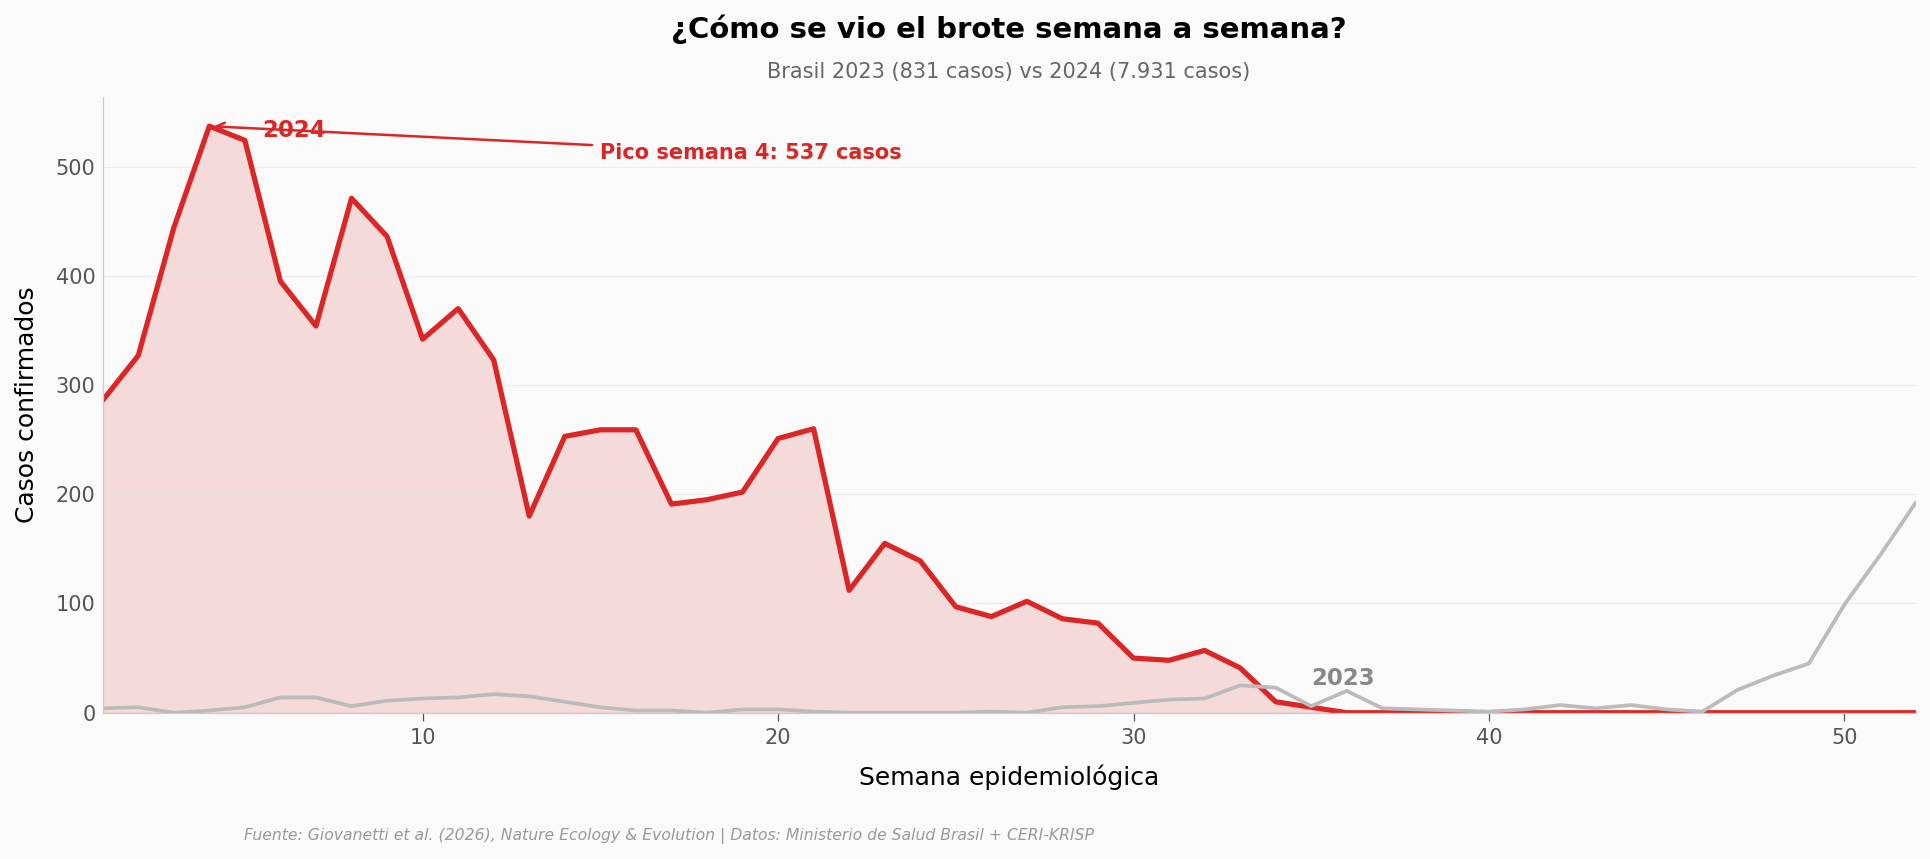

Total 2023: 831 casos | Total 2024: 7931 casos
Razón 2024/2023: 9.5×


In [2]:
# Pivot a semanas × año
pivot = semanales.pivot(index='semana_epi', columns='anio', values='casos').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(pivot.index, 0, pivot[2024], color=COLOR_2024, alpha=0.15)
ax.plot(pivot.index, pivot[2024], color=COLOR_2024, linewidth=2.5, label='2024')
ax.plot(pivot.index, pivot[2023], color=COLOR_2023, linewidth=1.8, label='2023')

# Inline labels
ax.text(PICO_SEMANA + 1.5, PICO_CASOS - 10, '2024', fontsize=11,
        color=COLOR_2024, fontweight='bold')
ax.text(35, 25, '2023', fontsize=11, color='#888888', fontweight='bold')

# Anotar pico
ax.annotate(f'Pico semana {PICO_SEMANA}: {PICO_CASOS} casos',
            xy=(PICO_SEMANA, PICO_CASOS),
            xytext=(15, PICO_CASOS - 30),
            fontsize=10, color=COLOR_2024, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_2024, lw=1.2))

ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Casos confirmados')
ax.set_title('¿Cómo se vio el brote semana a semana?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Brasil 2023 ({CASOS_2023:,} casos) vs 2024 ({CASOS_2024:,} casos)'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(1, 52)
ax.set_ylim(bottom=0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/casos_semanales.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Total 2023: {pivot[2023].sum():.0f} casos | Total 2024: {pivot[2024].sum():.0f} casos')
print(f'Razón 2024/2023: {pivot[2024].sum() / pivot[2023].sum():.1f}×')

La línea gris de 2023 apenas se levanta del eje. La curva de 2024 dispara en las primeras semanas y supera al año anterior por casi un orden de magnitud. El pico llega temprano — semana 4 — y la cola se mantiene alta durante todo el primer semestre.

Lo que cuenta este patrón: no fue un goteo, fue una explosión sincronizada. Cuando un virus brota así en múltiples regiones a la vez, la pregunta deja de ser "¿cuándo llegó?" y pasa a "¿cómo llegó tan rápido a tantos lugares?".

## Tres fotos, tres momentos

Para responder esa pregunta, miremos dónde aparecía el virus en tres momentos distintos: antes de mid-2023 (era pre-expansión, contenido en la Amazonía), justo antes del outbreak de 2024, y al final de 2024.

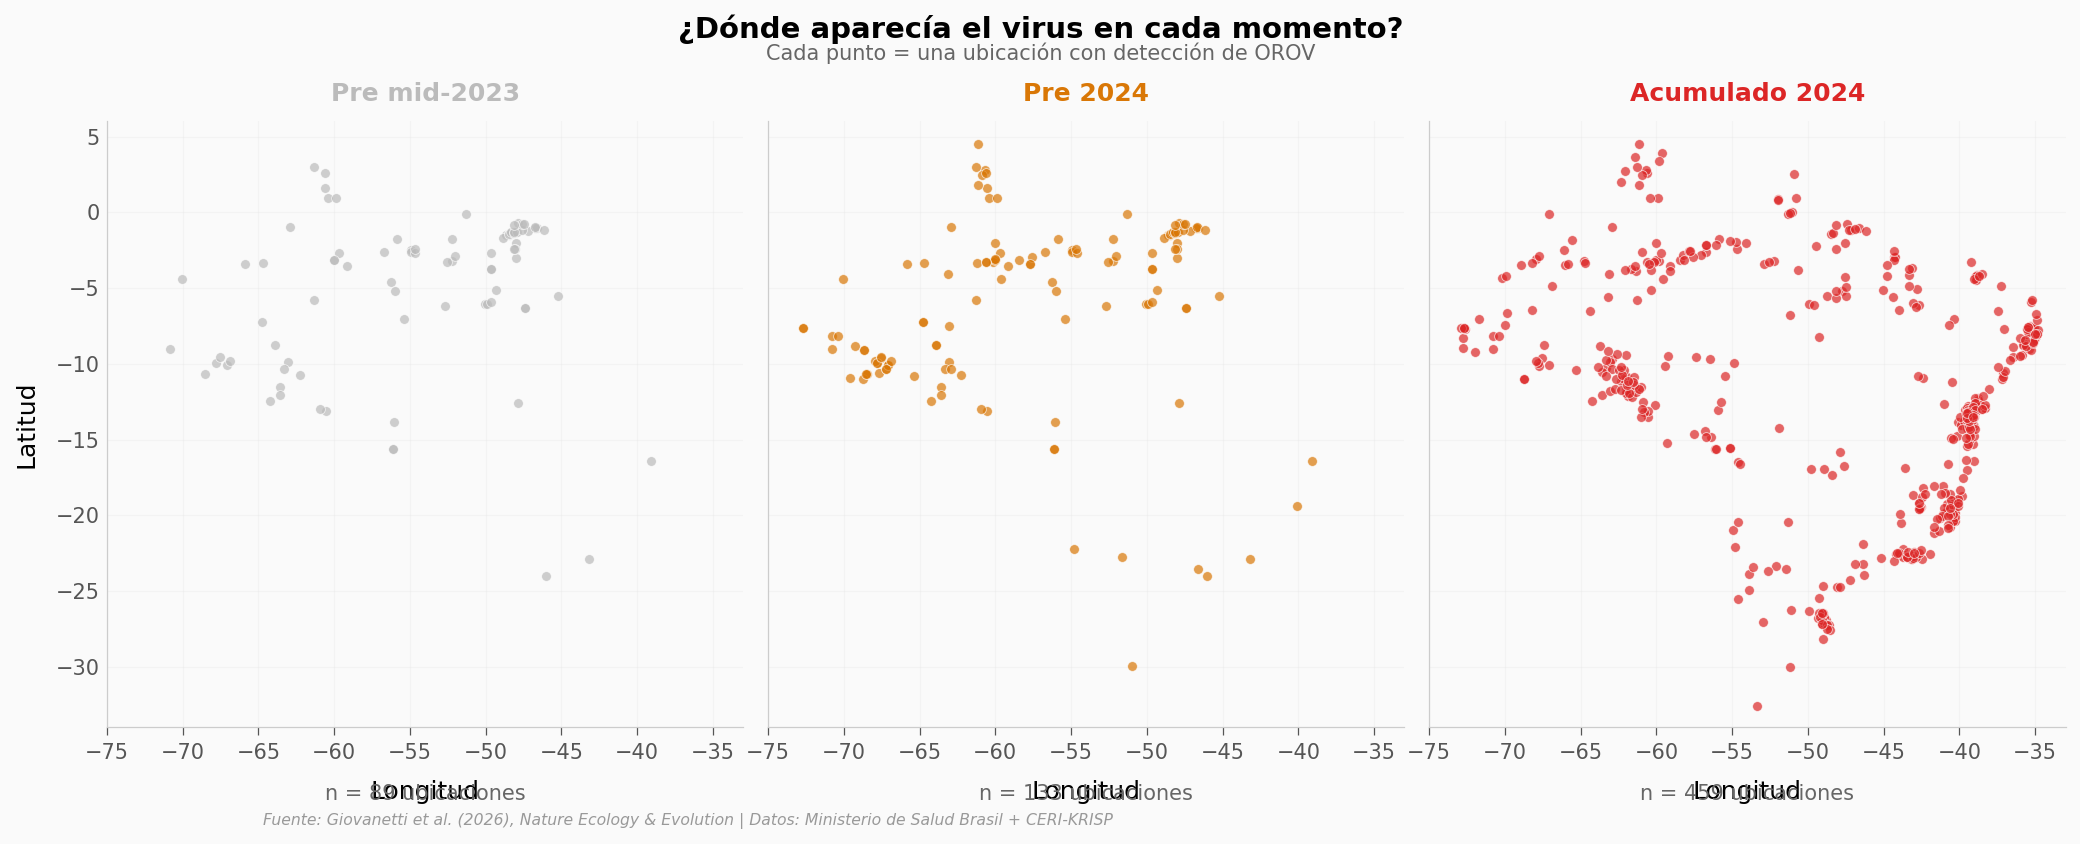

Pre mid-2023        : 89 puntos
Pre 2024            : 133 puntos
Acumulado 2024      : 459 puntos


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)

ordered = [
    ('pre_mid2023', 'Pre mid-2023', COLOR_PRE_MID2023),
    ('pre_2024',    'Pre 2024',     COLOR_PRE_2024),
    ('cumulative_2024', 'Acumulado 2024', COLOR_2024_FULL),
]

# Brasil: caja aproximada para todos los paneles
LON_MIN, LON_MAX = -75, -33
LAT_MIN, LAT_MAX = -34, 6

for ax, (key, label, color) in zip(axes, ordered):
    sub = ocurrencia[ocurrencia.periodo == key]
    n = len(sub)
    ax.scatter(sub.lon, sub.lat, color=color, s=22, alpha=0.7,
               edgecolors='white', linewidths=0.4, zorder=5)
    ax.set_title(label, fontsize=12, fontweight='bold', color=color, pad=10)
    ax.text(0.5, -0.12, f'n = {n} ubicaciones',
            transform=ax.transAxes, ha='center', fontsize=10, color='#666666')
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Latitud')
for ax in axes:
    ax.set_xlabel('Longitud')

fig.suptitle('¿Dónde aparecía el virus en cada momento?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.96,
         'Cada punto = una ubicación con detección de OROV',
         ha='center', fontsize=10, color='#666666')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/expansion_geografica.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
for key, label, _ in ordered:
    n = (ocurrencia.periodo == key).sum()
    print(f'{label:20s}: {n} puntos')

## ¿Qué tan rápido se movía el virus?

El genoma del Oropouche está partido en tres segmentos (L, M y S). El equipo reconstruyó el árbol genealógico de cada uno por separado — usando filogeografía bayesiana — y para cada árbol sacó 100 estimaciones de qué tan rápido se movía el virus por rama. Lo que nos queda: una distribución de velocidades en kilómetros por año, segmento a segmento.

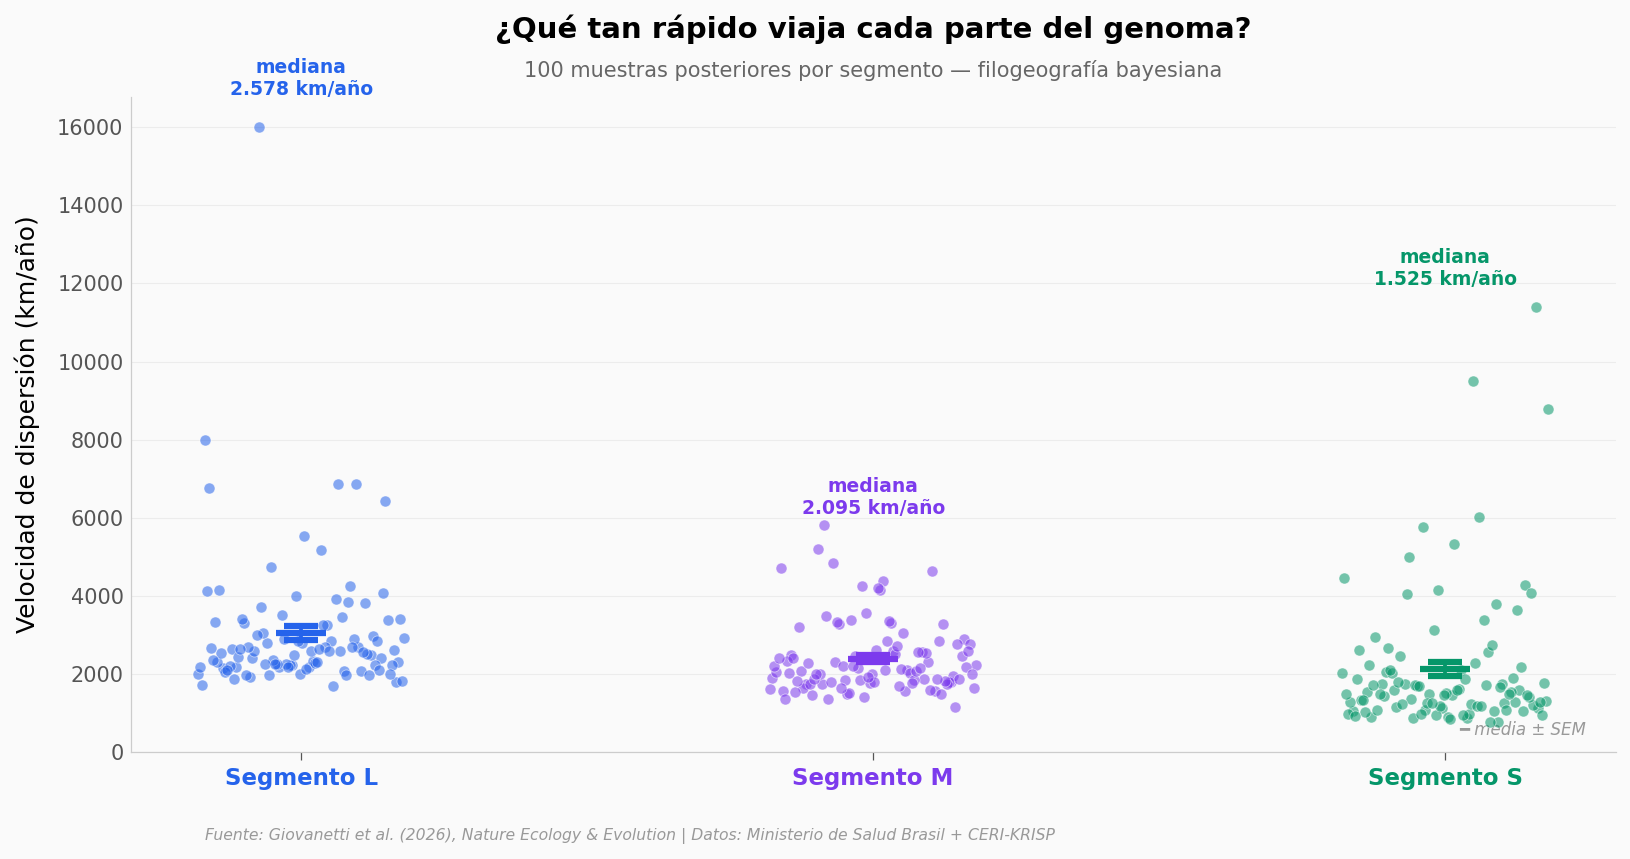

Segmento L: mediana=2578 km/año | IQR=[2203, 3273]
Segmento M: mediana=2095 km/año | IQR=[1785, 2638]
Segmento S: mediana=1525 km/año | IQR=[1166, 2125]


In [4]:
# Strip + barra de error (media ± SEM) por segmento
np.random.seed(42)
fig, ax = plt.subplots(figsize=(11, 5.5))

orden = ['L', 'M', 'S']
colores = ['#2563EB', '#7C3AED', '#059669']
positions = [0, 1, 2]

for i, (seg, color) in enumerate(zip(orden, colores)):
    vals = velocidades[velocidades.segmento == seg]['mean_branch_dispersal_velocity_km_yr'].values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.18, positions[i] + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=28, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], media, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3, capsize=8, capthick=1.6, zorder=6)
    # Anotar mediana arriba
    mediana = np.median(vals)
    ax.text(positions[i], vals.max() * 1.05,
            f"mediana\n{mediana:,.0f} km/año".replace(',', '.'),
            ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels([f'Segmento {s}' for s in orden], fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)

ax.set_ylabel('Velocidad de dispersión (km/año)')
ax.set_title('¿Qué tan rápido viaja cada parte del genoma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '100 muestras posteriores por segmento — filogeografía bayesiana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')
ax.set_ylim(bottom=0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/velocidades_segmento.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen
for seg in orden:
    vals = velocidades[velocidades.segmento == seg]['mean_branch_dispersal_velocity_km_yr']
    print(f'Segmento {seg}: mediana={vals.median():.0f} km/año | '
          f'IQR=[{vals.quantile(0.25):.0f}, {vals.quantile(0.75):.0f}]')

## ¿Eso es rápido?

Una velocidad de 1.500 a 2.500 km/año suena abstracta. Comparemos con lo que el vector — *Culicoides paraensis*, un jején diminuto — puede volar por sí mismo. Estudios de campo (Sellers, 1980) estiman 1 a 5 km al día como rango de vuelo natural. Eso da un techo de unos 1.825 km/año en línea recta — y solo si vuela todos los días en la misma dirección, que no es lo que hace.

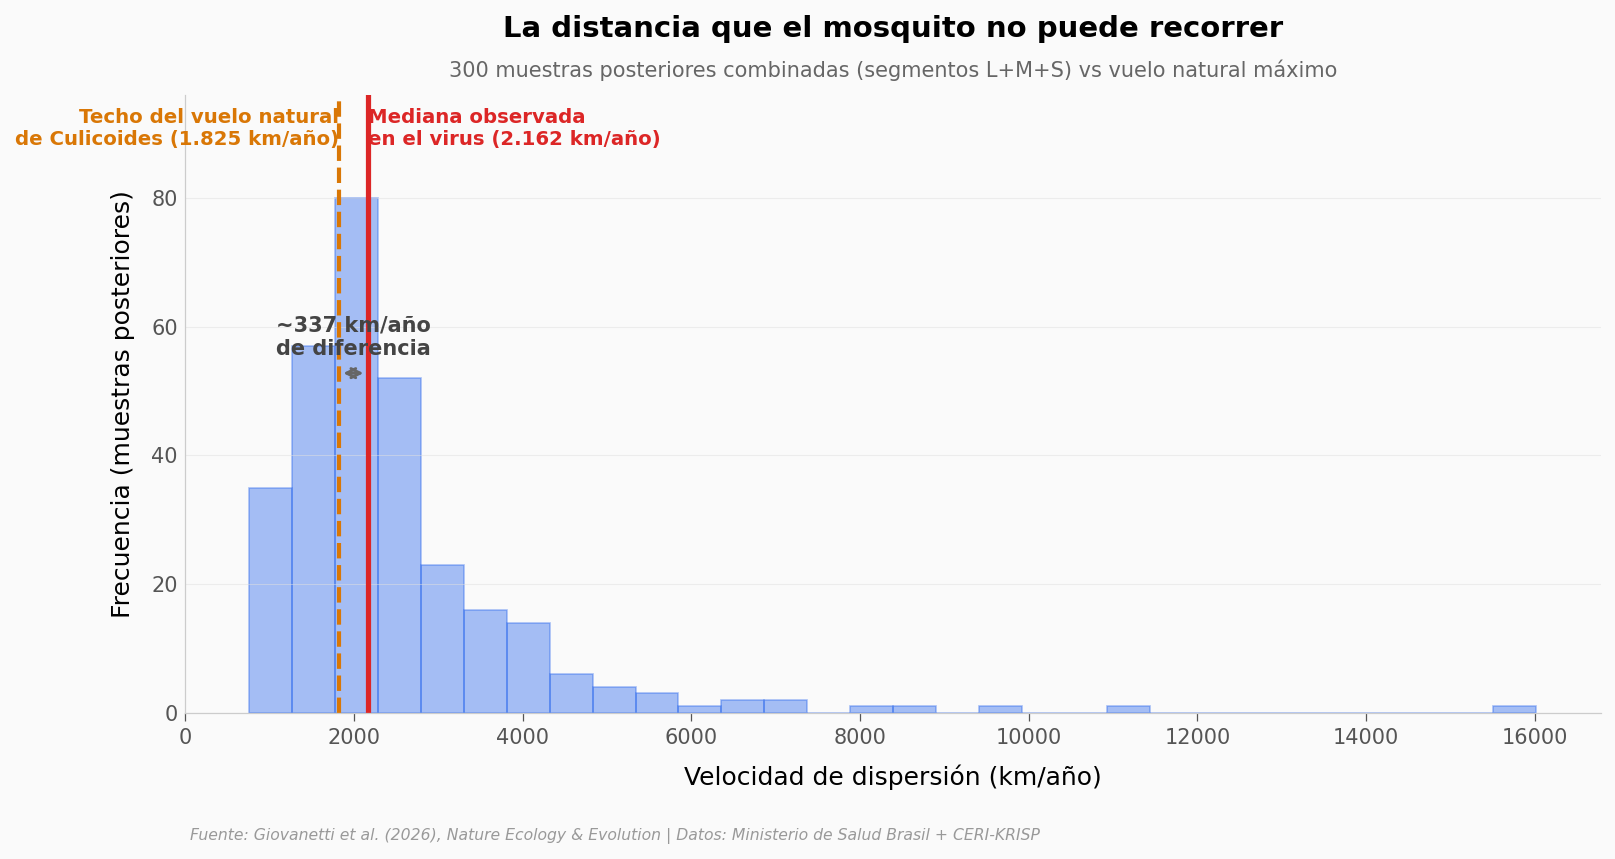

Muestras posteriores por encima del techo natural: 199/300 (66.3%)
Razón mediana virus / techo natural: 1.2×


In [5]:
# Histograma de las velocidades observadas vs línea del vuelo natural máximo
fig, ax = plt.subplots(figsize=(11, 5.5))

todas_vel = velocidades['mean_branch_dispersal_velocity_km_yr'].values
mediana_global = np.median(todas_vel)
techo_natural = CULICOIDES_KM_DIA_MAX * 365  # 1825 km/año

n, bins, patches = ax.hist(todas_vel, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Líneas: techo natural Culicoides + mediana observada
ax.axvline(x=techo_natural, color=COLOR_REFERENCIA, linewidth=2.0, linestyle='--')
ax.axvline(x=mediana_global, color='#DC2626', linewidth=2.5)

# Flecha entre las dos
ax.annotate('', xy=(mediana_global, y_max * 0.55),
            xytext=(techo_natural, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax.text((techo_natural + mediana_global) / 2, y_max * 0.58,
        f"~{mediana_global - techo_natural:,.0f} km/año\nde diferencia".replace(',', '.'),
        ha='center', fontsize=10, color='#444444', fontweight='bold')

# Etiquetas verticales
ax.text(techo_natural, y_max * 0.92,
        f"Techo del vuelo natural\nde Culicoides ({techo_natural:,} km/año)".replace(',', '.'),
        ha='right', fontsize=9.5, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(mediana_global, y_max * 0.92,
        f"Mediana observada\nen el virus ({mediana_global:,.0f} km/año)".replace(',', '.'),
        ha='left', fontsize=9.5, color='#DC2626', fontweight='bold')

ax.set_xlabel('Velocidad de dispersión (km/año)')
ax.set_ylabel('Frecuencia (muestras posteriores)')
ax.set_title('La distancia que el mosquito no puede recorrer',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '300 muestras posteriores combinadas (segmentos L+M+S) vs vuelo natural máximo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/anomalia_velocidad.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuántas observaciones quedan por encima del techo natural
above = (todas_vel > techo_natural).sum()
pct = above / len(todas_vel) * 100
print(f'Muestras posteriores por encima del techo natural: {above}/{len(todas_vel)} ({pct:.1f}%)')
print(f'Razón mediana virus / techo natural: {mediana_global / techo_natural:.1f}×')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El brote de 2024 fue 9× mayor que el de 2023 | ✅ | 7.931 vs 831 casos confirmados (datos del Ministerio de Salud, n=8.762 registros) |
| La expansión llegó a regiones no amazónicas | ✅ | Pasó de 11 estados en 2023 (concentrados en Amazonía: AM con 452 casos, AC 175, RR 153, RO 42; el resto con 1-2 casos cada uno) a 27 estados en 2024 — 16 nuevos, incluyendo costa atlántica (BA, CE) y Sudeste/Centro-Oeste (MG, GO, DF) |
| El virus se mueve más rápido que el vuelo natural del jején | ⚠️ | Mediana global 2.162 km/año (n=300 muestras posteriores combinadas L+M+S) vs techo natural 1.825 km/año. El 66% de las muestras posteriores (199/300) cae por encima del techo. El paper enmarca el rol del transporte humano como *probable* (no causación) |
| Los tres segmentos divergen en velocidad | ✅ | Medianas: L=2.578, M=2.095, S=1.525 km/año. Las distribuciones se solapan, pero L es consistentemente más rápido |

> **Limitaciones honestas del análisis:**
> - **Es observacional.** El paper detecta asociaciones y patrones. NO prueba que el cacao o el banano causen la expansión — son factores ambientales correlacionados con la presencia del vector.
> - **Velocidades estimadas, no medidas.** Las cifras de km/año vienen de inferencia bayesiana sobre árboles filogenéticos, no de seguimiento directo del virus.
> - **Comparación con vuelo de Culicoides es referencia.** El techo de 1.825 km/año asume vuelo en línea recta sin viento adverso — la realidad limita aún más, pero no podemos cuantificarlo aquí.
> - **No replicamos** el modelado de nicho ecológico (>200 archivos, requiere rasters geográficos pesados). Mencionamos sus hallazgos como contexto, no los verificamos.

## Ahora tú

1. ¿Qué pasa si miras los **5 estados con más casos de 2024**? Pista: filtra `estados[estados.anio==2024]` y ordena por `casos`.
2. La velocidad del segmento **S es la más baja de los tres**, pero su rango HPD95% es el más amplio (852–7463 km/año). ¿Qué tan ancho es el IQR de cada segmento? Pista: `velocidades.groupby('segmento').agg(...)`.
3. ¿En qué semana epidemiológica de 2024 se acumuló la **mitad de los casos**? Pista: `cumsum()` sobre la curva de 2024 y busca el 50%.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: top 5 estados de 2024
top5 = estados[estados.anio == 2024].nlargest(5, 'casos').reset_index(drop=True)
print('Top 5 estados con más casos en 2024:')
for _, row in top5.iterrows():
    pct = row.casos / CASOS_2024 * 100
    print(f'  {row.estado}: {int(row.casos):>5,} casos ({pct:.1f}% del total)'.replace(',', '.'))

Top 5 estados con más casos en 2024:
  AM: 3.168 casos (39.9% del total)
  RO: 1.663 casos (21.0% del total)
  BA:   896 casos (11.3% del total)
  ES:   433 casos (5.5% del total)
  AC:   280 casos (3.5% del total)


---

## Fuentes

**Paper**: [Dynamics and ecology of a multistage expansion of Oropouche virus in Brazil](https://doi.org/10.1038/s41559-026-03042-0)  
*Nature Ecology & Evolution, 2026-04-22*

**Dataset canónico**: [OROV_Expansion_Dynamics_Ecology — disease occurrence data, dispersal locations, dispersal statistics, OROPOUCHE_cases.xlsx](https://github.com/CERI-KRISP/OROV_Expansion_Dynamics_Ecology)  
*Repositorio CERI-KRISP — disease occurrence data, dispersal statistics, casos del Ministerio de Salud Brasil*

**Secuencias virales**: [GenBank — accessions PQ149810 et al.](https://www.ncbi.nlm.nih.gov/nuccore/PQ149810)  
*Base genómica de los árboles filogenéticos*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Notebook reproducible · Licencia: CC BY 4.0

*Este notebook acompaña a un video corto del canal [Ciencia a Mordiscos](https://www.youtube.com/@cienciaamordiscos). El video traduce los datos en una historia de 90 segundos; el notebook deja los datos visibles para quien quiera abrir la caja.*